In [1]:
%run header.ipynb

%config InlineBackend.figure_formats = ['svg']




The Fourier transform works only for signals that can be considered stationary 
within the segment to be analyzed.
Since most signals in music and audio signal processing to not meet that requirement, they need to be sliced into segments that can be considered stationary.
The *Short-Time Fourier Transform* (STFT) devides a signal into a sequence of
segments - also called frames - and calculates a Fourier transform for each frame.
Usually (but not necessarily) these segments are overlapping and of equal length.

The STFT can be useful for calculations and signal manipulations, as well as for 
visualization, since this shows the evolution of a signal's spectrum over time.
This visual representation is referred to as *spectrogram*.
 

-----

For a block-size  (also window-size or frame-size) of $N$ and a hop-size of $M$,
the DFT is calculated as follows:

$$
\mathrm{STFT}(m,k) = \sum_{n=-N/2}^{N/2} x[n+mM] e^{-j 2 \pi k \frac{n}{N}}
$$

The overlap of the STFT can be expressed as the difference or ratio of frame-size and hop-size:

Overlap (samples) $= N-M$

Overlap (%) $= \frac{N-M}{N}$

-----

# Typical Paramters 

Block-size and hop-size of an STFT are chosen with respect to the signals that need to be analyzed.
There are some relations that need to be cosidered:

- The larger the frames, the better the frequency resolution.
    - The shorter the frames, the more stationary within them. 
- The larger the overlap, the better the time resolution.
    - Very large overlaps lead to redundancy. 

In audio DSP, blocks should be long enough to incoude a full cycle of the lowest frequencies we are interested in.

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Derive a minimum length in samples for 48 kHz sampling rate. 
</div>

Block sizes are chosen to be a power of two to accomodate the FFT algorithms.
For audio signals at $f_s = 48 \mathrm{kHz}$ sampling rate, typical frame-sizes are 512, 1024 and 2048 samples. The singal duration $T$ for an $N=2048$ sample frame is:

$$T = \frac{N}{f_s} = 0.0426 \mathrm s$$

Typical overlaps are 50%.




------

# Window Function

The above equation is the most basic version of an STFT.
To improve the results, each frame can be multiplied with a so-called window function $w[n]$ before the transform. This window function has the same length as the anaysis blocks.

$$
\mathrm{STFT}(m,k) = \sum_{n=-N/2}^{N/2} x[n+mM] w[n] e^{-j 2 \pi k \frac{n}{N}}
$$




Window functions are used to reduce *spectral leakage*. Even when using no extra window at all, there is always a rectangular boxcar window when isolating a segment.

The introduction of the Fourier transform showed that a boxcar window is a sinc function in the frequency domain.
Together with the convolution theorem this means that when truncating a segment with a boxcar in the time domain, this represents a convolution in the freuency domain.



-----

## The Hann Window

Additional window functions have more suitable spectral features than a boxcar.
One example is the Hann window:

$$
w(n) = \frac{1}{L} \cos^2 \left( \frac{\pi n}{M} \right), ~\forall ~ n ~ \leq |L/2|
$$

The plots below show a Hann window with the corresponding Fourier transform.
In contrast to a boxcar it has a narrower *main lobe* and less prominent *side lobes*.

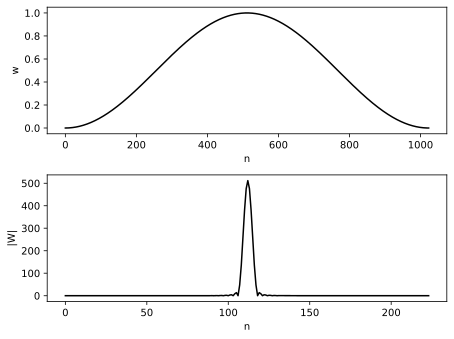

In [2]:
from scipy import fft 

w = signal.windows.hann(1024)


fig = plt.figure()

ax1 = plt.subplot(2,1,1)
ax1.plot(w,'k')
ax1.set_xlabel('n')
ax1.set_ylabel('w')

w = np.pad(w,1024)
W = fft.fftshift(fft.fft(w))


ax2 = plt.subplot(2,1,2)
ax2.plot(abs(W[1024+400:2048-400]),'k')
ax2.set_xlabel('n')
ax2.set_ylabel('|W|')

fig.tight_layout(pad=1)


-----

# STFT Example

For musical sounds with a pitch, the spectrogram shows the individual partials
as prominent horizontal lines. The following spectrogram of a sound,
recorded with a sampling rate of $f_s = 96\ \mathrm{kHz}$ is calculated with a framesize of $1024$ samples and an overlap of $512$ samples:


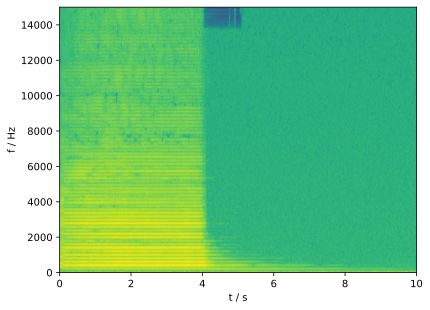

In [3]:
url = 'https://ringbuffer.org/download/ringbuffer_data/Sound_Synthesis_Introduction/Audio/SampLib_BuK_04.mp3'
x, fs = sf.read(io.BytesIO(urlopen(url).read()))

 
powerSpectrum, freqenciesFound, time, imageAxis = plt.specgram(x, NFFT=1024, noverlap = 512, Fs=fs);

plt.xlim((0,10))
plt.ylim((0,15000))

plt.ylabel('f / Hz');
plt.xlabel('t / s');
plt.show;


<div class="alert alert-block alert-info">
    <b>Exercise 1:</b> Explain the spectrogram. What sound could it be? What elemens can be observed?
</div>


<div class="alert alert-block alert-info">
    <b>Exercise 2:</b> Calculate the framesize and overlap in seconds. What is the maximum represented frequency?
</div>

------

[Listen to the sound.](https://ringbuffer.org/download/ringbuffer_data/Sound_Synthesis_Introduction/Audio/SampLib_BuK_04.mp3)

